In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from general_nn import NeuralNetwork
print("import success")

import success


# Activation Functions

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(y):
    return y * (1 - y)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def leaky_relu(x):
    return np.where(x > 0, x, x * 0.01)

def leaky_relu_derivative(x):
    return np.where(x > 0, 1.0, 0.01)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - x ** 2

## Digit Classification

In [34]:
df = pd.read_csv("train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
data = df.drop(["label"], axis=1).to_numpy()
targets = df["label"].to_numpy()

In [36]:
cm = NeuralNetwork([784, 392, 196, 10])

In [37]:
cm.train(150, data[:2000], targets[:2000], leaky_relu, leaky_relu_derivative, 0.001)

Avg Error for epoch 20: 2.0782130732899426e-05
Avg Error for epoch 40: 1.2564023128683678e-05
Avg Error for epoch 60: 1.0072817128170584e-05
Avg Error for epoch 80: 9.04659107901246e-06
Avg Error for epoch 100: 8.245393258893799e-06
Avg Error for epoch 120: 8.035259605520768e-06
Avg Error for epoch 140: 7.613869291024756e-06


In [38]:
print(cm.prediction_accuracy(data[6000:7001], targets[6000:7001]))

0.8671328671328671


In [39]:
print(cm.prediction_accuracy(data[4000:5001], targets[4000:5001]))

0.8861138861138861


## Linear Regression

In [40]:
regression_df = pd.read_csv("customers.csv")
regression_df = regression_df[["Time on App", "Length of Membership", "Yearly Amount Spent"]]
regression_df.head()

,Time on App,Length of Membership,Yearly Amount Spent
0,12.655651,4.082621,587.951054
1,11.109461,2.664034,392.204933
2,11.330278,4.104543,487.547505
3,13.717514,3.120179,581.852344
4,12.795189,4.446308,599.406092


In [41]:
len(regression_df)

500

In [42]:
data = regression_df.drop(["Yearly Amount Spent"], axis=1).to_numpy()
targets = regression_df["Yearly Amount Spent"].to_numpy()

In [51]:
rm = NeuralNetwork([2, 10, 5, 3, 1], type="regression")

In [52]:
rm.train(1000, data[:400], targets[:400], relu, relu_derivative, 0.01)

Avg Error for epoch 20: 2150.7627074268416
Avg Error for epoch 40: 1365.7735018819208
Avg Error for epoch 60: 1014.8832893716219
Avg Error for epoch 80: 1060.547924694346
Avg Error for epoch 100: 992.8284108715535
Avg Error for epoch 120: 960.280704027579
Avg Error for epoch 140: 941.0566884905131
Avg Error for epoch 160: 938.6720648682624
Avg Error for epoch 180: 925.1978266040088
Avg Error for epoch 200: 925.1952492883983
Avg Error for epoch 220: 928.9327922808848
Avg Error for epoch 240: 899.802790641531
Avg Error for epoch 260: 909.0605962437986
Avg Error for epoch 280: 892.7793735266162
Avg Error for epoch 300: 899.0901734566913
Avg Error for epoch 320: 895.5285451072709
Avg Error for epoch 340: 897.5615148039528
Avg Error for epoch 360: 902.6736255491492
Avg Error for epoch 380: 893.9709142810233
Avg Error for epoch 400: 887.9749100978812
Avg Error for epoch 420: 901.5226077984036
Avg Error for epoch 440: 906.0515855648936
Avg Error for epoch 460: 899.6248922398705
Avg Error for 

In [53]:
rm.prediction_accuracy(data[401:500], targets[401:500])

0.0036324639676097855

## Sin Wave Prediction

In [54]:
data = np.linspace(-10, 10, 10000)
data = data.reshape(-1, 1)
targets = np.cos(data)
targets = targets.reshape(-1, 1)

In [55]:
rm = NeuralNetwork([1, 50, 50, 50, 50, 1], type="regression")

In [56]:
rm.train(150, data, targets, tanh, tanh_derivative, 0.01)

Avg Error for epoch 20: 0.007894775503105947
Avg Error for epoch 40: 0.0032971333586989723
Avg Error for epoch 60: 0.0017725780086465294
Avg Error for epoch 80: 0.001517729824941861
Avg Error for epoch 100: 0.0013082290567460362
Avg Error for epoch 120: 0.0012218905001613255
Avg Error for epoch 140: 0.0011495828469062005


In [31]:
data = np.linspace(6.7, 9.5, 200)
data = data.reshape(-1, 1)
targets = np.cos(data)
targets = targets.reshape(-1, 1)
rm.prediction_accuracy(data, targets)

0.0036162299703515694

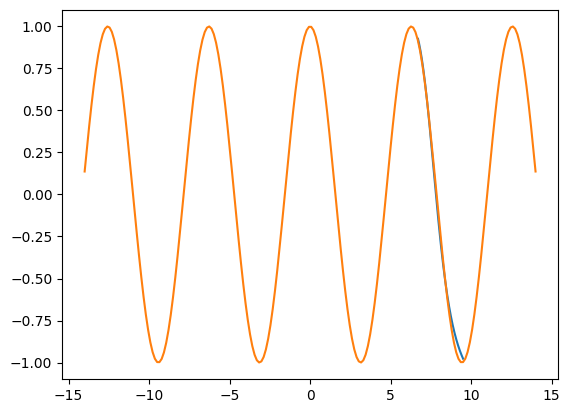

In [32]:
predict = rm.predict(data)
plt.plot(data, predict)
plt.plot(np.linspace(-14, 14, 200), np.cos(np.linspace(-14, 14, 200)))